## UMAP of pre-QC profiles comparing coSMicQC and PyOD ECOD QC status, with example flagged-cell images

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from cytodataframe import CytoDataFrame
from plotnine import (
    aes,
    element_text,
    facet_wrap,
    geom_point,
    ggplot,
    guide_legend,
    guides,
    labs,
    scale_color_manual,
    theme,
    theme_bw,
)
from plotnine.options import set_option
from pycytominer import annotate, feature_select, normalize
from pyod.models.ecod import ECOD
from skimage import exposure


## Helper functions

In [2]:
# -----------------------------
# Mild histogram equalization
# -----------------------------
def mild_histogram_equalization(image: np.ndarray, sample: np.ndarray) -> np.ndarray:
    """
    Apply mild histogram equalization to an image.

    Parameters:
    image (np.ndarray): The input image.
    sample (np.ndarray): The sample image for reference.

    Returns:
    np.ndarray: The equalized image.
    """
    return exposure.equalize_adapthist(
        image,
        clip_limit=0.01
    )


In [3]:
# Set figure directory
figure_dir = Path("./figures")
figure_dir.mkdir(exist_ok=True)

# Load dataframe
no_QC_df = pd.read_parquet(
    Path(
        "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/3.process_cfret_features/data/converted_profiles/localhost230405150001_converted.parquet"
    )
)

# Build Hoechst filenames (d0)
no_QC_df["Image_FileName_Hoechst"] = (
    no_QC_df["Image_Metadata_Plate"]
    + "_"
    + no_QC_df["Image_Metadata_Well"]
    + no_QC_df["Image_Metadata_Site"]
    + "d0_illumcorrect.tiff"
)

# Build Actin filenames (d4)
no_QC_df["Image_FileName_Actin"] = (
    no_QC_df["Image_Metadata_Plate"]
    + "_"
    + no_QC_df["Image_Metadata_Well"]
    + no_QC_df["Image_Metadata_Site"]
    + "d4_illumcorrect.tiff"
)

print(no_QC_df.shape)
no_QC_df.head()


(25859, 2018)


,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,Metadata_Image_Count_Cells,Metadata_ImageNumber,Image_Metadata_Plate,Image_Metadata_Site,Image_Metadata_Well,Metadata_Cells_Number_Object_Number,...,Nuclei_Texture_Variance_Mitochondria_3_00_256,Nuclei_Texture_Variance_Mitochondria_3_01_256,Nuclei_Texture_Variance_Mitochondria_3_02_256,Nuclei_Texture_Variance_Mitochondria_3_03_256,Nuclei_Texture_Variance_PM_3_00_256,Nuclei_Texture_Variance_PM_3_01_256,Nuclei_Texture_Variance_PM_3_02_256,Nuclei_Texture_Variance_PM_3_03_256,Image_FileName_Hoechst,Image_FileName_Actin
0,221.046761,137.115493,246.602800,109.285755,40,1,localhost230405150001,f00,B02,1,...,0.529422,0.478064,0.489459,0.475133,2.703146,2.664110,2.650578,2.664691,localhost230405150001_B02f00d0_illumcorrect.tiff,localhost230405150001_B02f00d4_illumcorrect.tiff
1,690.596142,183.067828,716.170091,177.132195,40,1,localhost230405150001,f00,B02,2,...,46.883295,50.496897,42.311975,39.973584,4.376776,4.567953,4.220630,4.058367,localhost230405150001_B02f00d0_illumcorrect.tiff,localhost230405150001_B02f00d4_illumcorrect.tiff
2,626.561490,206.923698,623.943740,199.906440,40,1,localhost230405150001,f00,B02,3,...,0.970588,0.952145,0.950279,0.908622,2.568485,2.578927,2.556851,2.541355,localhost230405150001_B02f00d0_illumcorrect.tiff,localhost230405150001_B02f00d4_illumcorrect.tiff
3,559.448583,220.688160,528.646623,196.955552,40,1,localhost230405150001,f00,B02,4,...,2.511639,2.456358,2.509622,2.547159,3.866945,4.011720,4.004412,3.866034,localhost230405150001_B02f00d0_illumcorrect.tiff,localhost230405150001_B02f00d4_illumcorrect.tiff
4,909.019946,247.694340,897.965996,253.621836,40,1,localhost230405150001,f00,B02,5,...,5.823674,6.553608,6.620230,5.453092,2.029099,2.044566,2.038007,2.058557,localhost230405150001_B02f00d0_illumcorrect.tiff,localhost230405150001_B02f00d4_illumcorrect.tiff


In [4]:
# Identify columns to drop (metadata only)
drop_cols = no_QC_df.columns[
    no_QC_df.columns.str.startswith("Image_Metadata")
    | no_QC_df.columns.str.startswith("Metadata_")
    | no_QC_df.columns.str.startswith("Image_FileName")
]

# Feature matrix
X = no_QC_df.drop(columns=drop_cols)

# Drop columns with ANY NaNs in features (required for ECOD to work)
X_clean = X.loc[:, ~X.isna().any()]

# Fit ECOD
ecod = ECOD(contamination=0.193, n_jobs=-1)
ecod.fit(X_clean)

# Predict labels
ecod_labels = ecod.labels_

# Store results back ONLY for valid rows
no_QC_df["ECOD_flag"] = np.nan
no_QC_df.loc[X_clean.index, "ECOD_flag"] = ecod_labels
# Print number of outliers detected
print(f"Number of outliers detected by ECOD: {np.sum(ecod_labels)}")


[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   2 out of  16 | elapsed:    4.0s remaining:   28.3s
[Parallel(n_jobs=16)]: Done  16 out of  16 | elapsed:    5.6s finished
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/pyod/models/ecod.py:25: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.


Number of outliers detected by ECOD: 4991


In [5]:
# Set platemap path
platemap_path = Path(
    "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/metadata/localhost230405150001_platemap.csv"
)
# Load platemap
platemap_df = pd.read_csv(platemap_path)

# Step 1: Annotation
print("Running annotation...")
annotated_df = annotate(
    profiles=no_QC_df,
    platemap=platemap_df,
    join_on=["Metadata_well_position", "Image_Metadata_Well"],
)

# Rename columns using the rename() function
column_name_mapping = {
    "Image_Metadata_Site": "Metadata_Site",
}

annotated_df.rename(columns=column_name_mapping, inplace=True)

# Drop any row that is flagged by ECOD as an outlier
annotated_df_no_ECOD_outliers = annotated_df[annotated_df["ECOD_flag"] == 0]

# Step 2: Normalization
print("Running normalization...")
normalized_df_no_ECOD_outliers = normalize(
    profiles=annotated_df_no_ECOD_outliers,
    method="standardize",
)

# Step 3: Feature selection
print("Running feature selection...")
norm_fs_df_no_ECOD_outliers = feature_select(
    normalized_df_no_ECOD_outliers,
    operation=[
        "variance_threshold",
        "correlation_threshold",
        "blocklist",
        "drop_na_columns",
    ],
    na_cutoff=0,
)

print(norm_fs_df_no_ECOD_outliers.shape)
norm_fs_df_no_ECOD_outliers.head()

# Save
output_dir = Path("./data")
output_dir.mkdir(exist_ok=True)
norm_fs_df_no_ECOD_outliers.to_parquet(f"{output_dir}/ecod_retransplant_norm_fs.parquet")


Running annotation...
Running normalization...
Running feature selection...
(20868, 737)


In [6]:
# Assign ECOD labels directly (same row order preserved)
no_QC_df["ECOD_flag"] = ecod.labels_

# Counts
flagged_cells = no_QC_df["ECOD_flag"].sum()
total_cells = len(no_QC_df)
fraction_flagged = flagged_cells / total_cells

print(f"Total cells: {total_cells}")
print(f"Flagged cells (ECOD): {flagged_cells}")
print(f"Fraction flagged: {fraction_flagged:.4f}")


Total cells: 25859
Flagged cells (ECOD): 4991
Fraction flagged: 0.1930


In [7]:
# Load in dataframe with each cell that passed or failed QC from coSMicQC
cosmicqc_df = pd.read_parquet("../figure_3/umap_embeddings/pre_QC_umap_embeddings.parquet")

print(cosmicqc_df.shape)
cosmicqc_df.head()


(25859, 23)


,Metadata_WellRow,Metadata_WellCol,Metadata_heart_number,Metadata_cell_type,Metadata_heart_failure_type,Metadata_treatment,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,...,Metadata_Well,Metadata_Cells_Number_Object_Number,Metadata_Cytoplasm_Parent_Cells,Metadata_Cytoplasm_Parent_Nuclei,Metadata_Nuclei_Number_Object_Number,Metadata_Site,Metadata_Treatment_CellType_ID,UMAP0,UMAP1,Metadata_QC_status
0,B,2,9,diseased,rejected,control,221.046761,137.115493,246.602800,109.285755,...,B02,1,1,6,6,f00,DMSO-control diseased,-2.078834,4.570251,passed
1,B,2,9,diseased,rejected,control,690.596142,183.067828,716.170091,177.132195,...,B02,2,2,7,7,f00,DMSO-control diseased,-1.326478,7.692071,passed
2,B,2,9,diseased,rejected,control,626.561490,206.923698,623.943740,199.906440,...,B02,3,3,8,8,f00,DMSO-control diseased,-1.747116,8.019854,passed
3,B,2,9,diseased,rejected,control,559.448583,220.688160,528.646623,196.955552,...,B02,4,4,9,9,f00,DMSO-control diseased,-2.015016,5.848380,passed
4,B,2,9,diseased,rejected,control,909.019946,247.694340,897.965996,253.621836,...,B02,5,5,10,10,f00,DMSO-control diseased,-0.918467,5.391689,passed


In [8]:
# Filter for rows where ECOD flagged cells as outliers
no_QC_df = no_QC_df.copy()

# Update plate, well, and site metadata to drop Image_ prefix
no_QC_df = no_QC_df.rename(
    columns=lambda c: c.replace("Image_", "") if c.startswith("Image_") else c
)
ECOD_outliers = no_QC_df[no_QC_df["ECOD_flag"] == 1].copy()

# Filter for only rows where cells failed coSMicQC
cosmicqc_df = cosmicqc_df.copy()
cosmic_outliers = cosmicqc_df[cosmicqc_df["Metadata_QC_status"] == "failed"].copy()

key_cols = [
    "Metadata_Plate",
    "Metadata_Well",
    "Metadata_Site",
    "Metadata_Nuclei_Location_Center_X",
    "Metadata_Nuclei_Location_Center_Y",
]

ECOD_outliers["cell_key"] = ECOD_outliers[key_cols].astype(str).agg("_".join, axis=1)
cosmic_outliers["cell_key"] = (
    cosmic_outliers[key_cols].astype(str).agg("_".join, axis=1)
)

# --- SETS FOR COMPARISON ---
ecod_set = set(ECOD_outliers["cell_key"])
cosmic_set = set(cosmic_outliers["cell_key"])

overlap = ecod_set & cosmic_set

print("ECOD outliers:", len(ecod_set))
print("coSMicQC outliers:", len(cosmic_set))
print("Overlap:", len(overlap))
print("ECOD overlap fraction:", len(overlap) / len(ecod_set))
print("coSMicQC overlap fraction:", len(overlap) / len(cosmic_set))


ECOD outliers: 4991
coSMicQC outliers: 4994
Overlap: 2337
ECOD overlap fraction: 0.4682428371067922
coSMicQC overlap fraction: 0.46796155386463756


In [9]:
# --- normalize column names so key_cols exist in both dfs ---
no_QC_df = no_QC_df.copy()
cosmicqc_df = cosmicqc_df.copy()

no_QC_df.columns = no_QC_df.columns.str.replace("Image_", "", regex=False)
cosmicqc_df.columns = cosmicqc_df.columns.str.replace("Image_", "", regex=False)

# --- key columns (now valid after normalization) ---
key_cols = [
    "Metadata_Plate",
    "Metadata_Well",
    "Metadata_Site",
    "Metadata_Nuclei_Location_Center_X",
    "Metadata_Nuclei_Location_Center_Y",
]

# --- create ECOD side key first ---
no_QC_df["cell_key"] = no_QC_df[key_cols].astype(str).agg("_".join, axis=1)

ecod_lookup = no_QC_df[
    ["cell_key", "ECOD_flag"]
    + [
        c
        for c in no_QC_df.columns
        if "BoundingBox" in c
        or "bounding" in c.lower()
        or "FileName" in c
        or "filename" in c.lower()
    ]
].copy()

# --- cosmicQC side ---
cosmicqc_df["cell_key"] = cosmicqc_df[key_cols].astype(str).agg("_".join, axis=1)

# --- merge ---
cosmicqc_df = cosmicqc_df.merge(ecod_lookup, on="cell_key", how="left")

cosmicqc_df["ECOD_flag"] = cosmicqc_df["ECOD_flag"].fillna(-1)

cosmicqc_df["ECOD_group"] = cosmicqc_df["ECOD_flag"].map(
    {1: "ECOD_outlier", 0: "ECOD_inlier", -1: "ECOD_missing"}
)

print("ECOD outliers:", (cosmicqc_df["ECOD_flag"] == 1).sum())
print("ECOD inliers:", (cosmicqc_df["ECOD_flag"] == 0).sum())
print("ECOD missing:", (cosmicqc_df["ECOD_flag"] == -1).sum())

cosmicqc_df.head()


ECOD outliers: 4991
ECOD inliers: 20868
ECOD missing: 0


,Metadata_WellRow,Metadata_WellCol,Metadata_heart_number,Metadata_cell_type,Metadata_heart_failure_type,Metadata_treatment,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,...,Cells_AreaShape_BoundingBoxMinimum_X,Cells_AreaShape_BoundingBoxMinimum_Y,Nuclei_AreaShape_BoundingBoxArea,Nuclei_AreaShape_BoundingBoxMaximum_X,Nuclei_AreaShape_BoundingBoxMaximum_Y,Nuclei_AreaShape_BoundingBoxMinimum_X,Nuclei_AreaShape_BoundingBoxMinimum_Y,FileName_Hoechst,FileName_Actin,ECOD_group
0,B,2,9,diseased,rejected,control,221.046761,137.115493,246.602800,109.285755,...,109.0,14.0,2310.0,242.0,165.0,200.0,110.0,localhost230405150001_B02f00d0_illumcorrect.tiff,localhost230405150001_B02f00d4_illumcorrect.tiff,ECOD_inlier
1,B,2,9,diseased,rejected,control,690.596142,183.067828,716.170091,177.132195,...,640.0,96.0,2128.0,710.0,211.0,672.0,155.0,localhost230405150001_B02f00d0_illumcorrect.tiff,localhost230405150001_B02f00d4_illumcorrect.tiff,ECOD_inlier
2,B,2,9,diseased,rejected,control,626.561490,206.923698,623.943740,199.906440,...,568.0,127.0,2838.0,648.0,241.0,605.0,175.0,localhost230405150001_B02f00d0_illumcorrect.tiff,localhost230405150001_B02f00d4_illumcorrect.tiff,ECOD_inlier
3,B,2,9,diseased,rejected,control,559.448583,220.688160,528.646623,196.955552,...,445.0,131.0,2496.0,587.0,246.0,535.0,198.0,localhost230405150001_B02f00d0_illumcorrect.tiff,localhost230405150001_B02f00d4_illumcorrect.tiff,ECOD_inlier
4,B,2,9,diseased,rejected,control,909.019946,247.694340,897.965996,253.621836,...,832.0,207.0,2360.0,930.0,277.0,890.0,218.0,localhost230405150001_B02f00d0_illumcorrect.tiff,localhost230405150001_B02f00d4_illumcorrect.tiff,ECOD_inlier


In [10]:
cosmicqc_df["QC_combined_group"] = "unknown"

failed = cosmicqc_df["Metadata_QC_status"] == "failed"
passed = cosmicqc_df["Metadata_QC_status"] == "passed"
ecod = cosmicqc_df["ECOD_flag"]  # 0/1 ints

cosmicqc_df.loc[failed & (ecod == 1), "QC_combined_group"] = "both_flagged"
cosmicqc_df.loc[failed & (ecod == 0), "QC_combined_group"] = "coSMicQC_only"
cosmicqc_df.loc[passed & (ecod == 1), "QC_combined_group"] = "ECOD_only"
cosmicqc_df.loc[passed & (ecod == 0), "QC_combined_group"] = "not_flagged"

cosmicqc_df["QC_combined_group"] = pd.Categorical(
    cosmicqc_df["QC_combined_group"],
    categories=["both_flagged", "coSMicQC_only", "ECOD_only", "not_flagged"],
    ordered=True,
)

cosmicqc_df.head()


,Metadata_WellRow,Metadata_WellCol,Metadata_heart_number,Metadata_cell_type,Metadata_heart_failure_type,Metadata_treatment,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,...,Cells_AreaShape_BoundingBoxMinimum_Y,Nuclei_AreaShape_BoundingBoxArea,Nuclei_AreaShape_BoundingBoxMaximum_X,Nuclei_AreaShape_BoundingBoxMaximum_Y,Nuclei_AreaShape_BoundingBoxMinimum_X,Nuclei_AreaShape_BoundingBoxMinimum_Y,FileName_Hoechst,FileName_Actin,ECOD_group,QC_combined_group
0,B,2,9,diseased,rejected,control,221.046761,137.115493,246.602800,109.285755,...,14.0,2310.0,242.0,165.0,200.0,110.0,localhost230405150001_B02f00d0_illumcorrect.tiff,localhost230405150001_B02f00d4_illumcorrect.tiff,ECOD_inlier,not_flagged
1,B,2,9,diseased,rejected,control,690.596142,183.067828,716.170091,177.132195,...,96.0,2128.0,710.0,211.0,672.0,155.0,localhost230405150001_B02f00d0_illumcorrect.tiff,localhost230405150001_B02f00d4_illumcorrect.tiff,ECOD_inlier,not_flagged
2,B,2,9,diseased,rejected,control,626.561490,206.923698,623.943740,199.906440,...,127.0,2838.0,648.0,241.0,605.0,175.0,localhost230405150001_B02f00d0_illumcorrect.tiff,localhost230405150001_B02f00d4_illumcorrect.tiff,ECOD_inlier,not_flagged
3,B,2,9,diseased,rejected,control,559.448583,220.688160,528.646623,196.955552,...,131.0,2496.0,587.0,246.0,535.0,198.0,localhost230405150001_B02f00d0_illumcorrect.tiff,localhost230405150001_B02f00d4_illumcorrect.tiff,ECOD_inlier,not_flagged
4,B,2,9,diseased,rejected,control,909.019946,247.694340,897.965996,253.621836,...,207.0,2360.0,930.0,277.0,890.0,218.0,localhost230405150001_B02f00d0_illumcorrect.tiff,localhost230405150001_B02f00d4_illumcorrect.tiff,ECOD_inlier,not_flagged


,ECOD_flag,FileName_Hoechst,FileName_Actin,Metadata_Well,Metadata_Site
18671,1,,,E09,f05
7325,1,,,C06,f12
18300,1,,,E06,f03
18334,1,,,E06,f06
18371,1,,,E06,f12

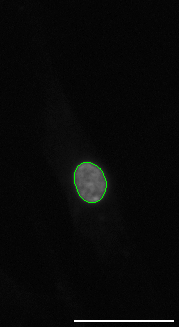
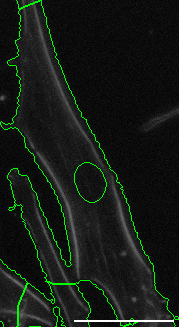
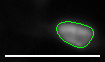
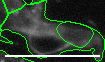
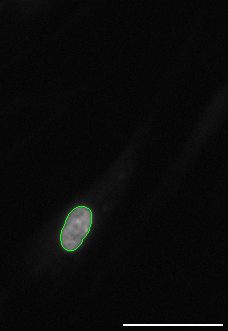
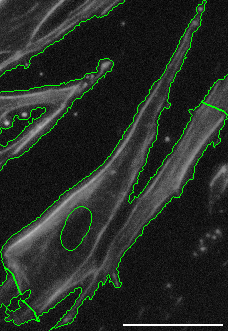
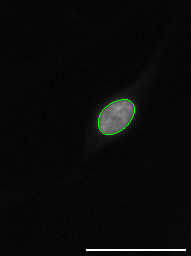
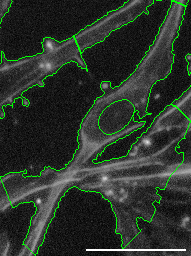
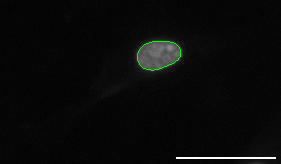
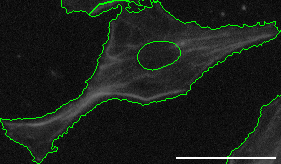

In [11]:
# Filter cosmicqc_df
failed_ecod_df = cosmicqc_df[
    (cosmicqc_df["ECOD_flag"] == 1)
    & (cosmicqc_df["Metadata_QC_status"] != "failed")
    & (cosmicqc_df["Metadata_Well"].isin(["C09", "E09", "C06", "E06"]))
]

failed_ecod_df_cdf = CytoDataFrame(
    data=failed_ecod_df,
    data_context_dir=Path(
        "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/1.preprocessing_data/Corrected_Images/localhost230405150001"
    ),
    data_outline_context_dir=Path(
        "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/2.cellprofiler_processing/cp_output/localhost230405150001/outlines"
    ),
    image_adjustment=mild_histogram_equalization,
    display_options={
        "brightness": 1,
        "um_per_pixel": 1,
        "center_dot": False,
        "scale_bar": {
            "length_um": 100,
            "location": "lower right",
            "color": (255, 255, 255),
            "thickness_px": 2,
            "margin_px": 5,
        },
    },
)[
    [
        "ECOD_flag",
        "FileName_Hoechst",
        "FileName_Actin",
        "Metadata_Well",
        "Metadata_Site",
    ]
]

failed_ecod_df_cdf.sample(n=5, random_state=42)


,ECOD_flag,FileName_Hoechst,FileName_Actin,Metadata_Well,Metadata_Site
7114,0,,,C06,f02
7403,0,,,C06,f14
7092,0,,,C06,f02
8626,0,,,C09,f10
7116,0,,,C06,f02

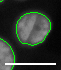
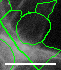
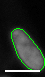
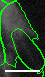
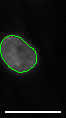
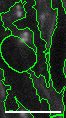
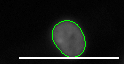
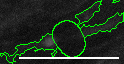
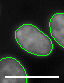
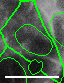

In [12]:
# Filter cosmicqc_df
failed_cosmicqc_df = cosmicqc_df[
    (cosmicqc_df["ECOD_flag"] == 0)
    & (cosmicqc_df["Metadata_QC_status"] == "failed")
    & (cosmicqc_df["Metadata_Well"].isin(["C09", "E09", "C06", "E06"]))
]

failed_cosmicqc_df_cdf = CytoDataFrame(
    data=failed_cosmicqc_df,
    data_context_dir=Path(
        "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/1.preprocessing_data/Corrected_Images/localhost230405150001"
    ),
    data_outline_context_dir=Path(
        "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/2.cellprofiler_processing/cp_output/localhost230405150001/outlines"
    ),
    image_adjustment=mild_histogram_equalization,
    display_options={
        "brightness": 1,
        "um_per_pixel": 1,
        "center_dot": False,
        "scale_bar": {
            "length_um": 100,
            "location": "lower right",
            "color": (255, 255, 255),
            "thickness_px": 2,
            "margin_px": 5,
        },
    },
)[
    [
        "ECOD_flag",
        "FileName_Hoechst",
        "FileName_Actin",
        "Metadata_Well",
        "Metadata_Site",
    ]
]

failed_cosmicqc_df_cdf.sample(n=5, random_state=42)


In [13]:
# Update QC_combined_group to have more descriptive labels
cosmicqc_df["QC_combined_group"] = cosmicqc_df["QC_combined_group"].replace(
    {
        "not_flagged": "Did not fail QC",
        "ECOD_only": "PyOD ECOD only",
        "coSMicQC_only": "coSMicQC only",
        "both_flagged": "Failed both",
    }
)

# Update treatment-cell type IDs for plain English formatting
cosmicqc_df["Metadata_Treatment_CellType_ID"] = cosmicqc_df[
    "Metadata_Treatment_CellType_ID"
].replace(
    {
        "control_diseased": "DMSO-control diseased",
        "treatment1_diseased": "Treatment 1 diseased",
        "treatment2_diseased": "Treatment 2 diseased",
        "control_healthy": "DMSO-control healthy",
        "treatment1_healthy": "Treatment 1 healthy",
        "treatment2_healthy": "Treatment 2 healthy",
    }
)

print(
    "Unique Treatment_CellType_IDs:",
    cosmicqc_df["Metadata_Treatment_CellType_ID"].unique(),
)


Unique Treatment_CellType_IDs: ['DMSO-control diseased' 'Treatment 2 diseased' 'Treatment 1 diseased'
 'DMSO-control healthy' 'Treatment 2 healthy' 'Treatment 1 healthy']


/tmp/ipykernel_2331162/3296929239.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.


In [14]:
order = {
    "DMSO-control": 0,
    "Treatment 1": 1,
    "Treatment 2": 2,
}

facet_levels = sorted(
    cosmicqc_df["Metadata_Treatment_CellType_ID"].dropna().unique(),
    key=lambda x: (
        next((v for k, v in order.items() if str(x).startswith(k)), 999),
        str(x),
    ),
)

print(facet_levels)  # <-- check this is in the order you want

cosmicqc_df = cosmicqc_df.assign(
    Metadata_Treatment_CellType_ID=pd.Categorical(
        cosmicqc_df["Metadata_Treatment_CellType_ID"],
        categories=facet_levels,
        ordered=True,
    )
)


['DMSO-control diseased', 'DMSO-control healthy', 'Treatment 1 diseased', 'Treatment 1 healthy', 'Treatment 2 diseased', 'Treatment 2 healthy']


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 17 x 9 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/ECOD_vs_cosmicqc_umap_retransplantation_plate.png


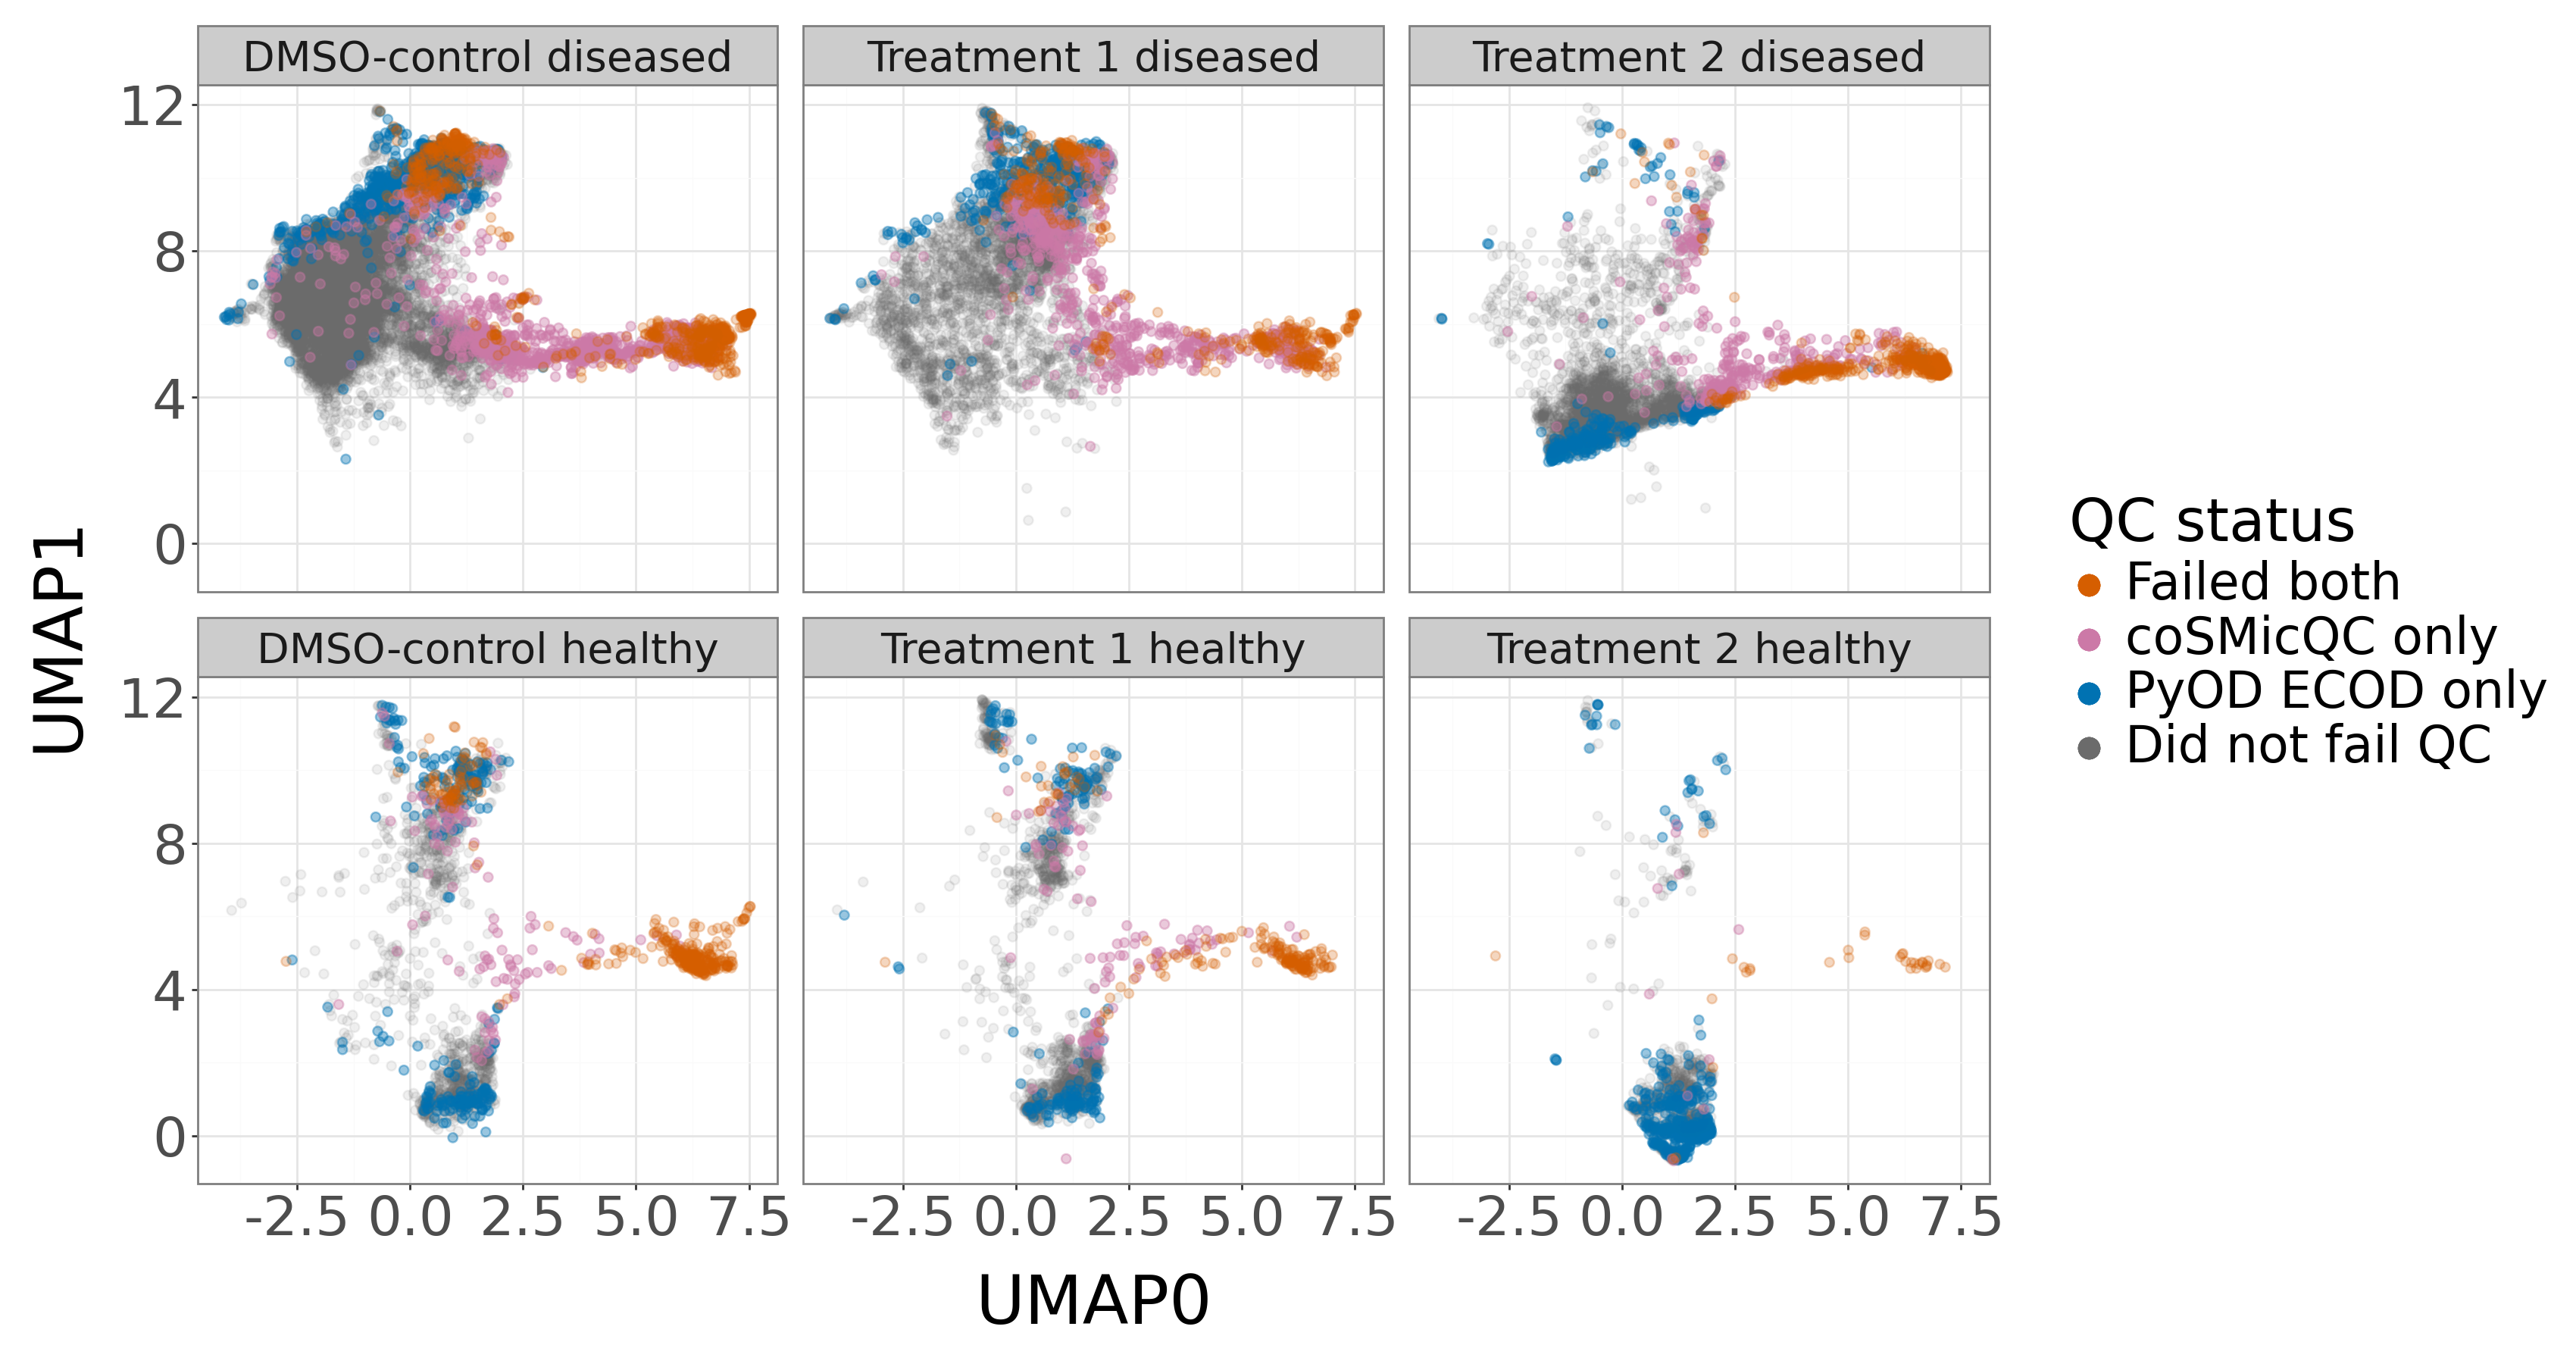

In [15]:
# Set the figure size
height = 9
width = 17
set_option("figure_size", (width, height))

# Plot UMAP of non-QC profiles labelled with QC status and
# faceted by treatment and cell type
p = (
    ggplot(
        cosmicqc_df,
        aes(x="UMAP0", y="UMAP1", color="QC_combined_group"),
    )
    + labs(
        color="QC status",
    )
    + geom_point(
        data=cosmicqc_df.query("QC_combined_group == 'Did not fail QC'"),
        mapping=aes(x="UMAP0", y="UMAP1", color="QC_combined_group"),
        alpha=0.1,
        size=2,
    )
    + geom_point(
        data=cosmicqc_df.query("QC_combined_group == 'PyOD ECOD only'"),
        mapping=aes(x="UMAP0", y="UMAP1", color="QC_combined_group"),
        alpha=0.4,
        size=2,
    )
    + geom_point(
        data=cosmicqc_df.query("QC_combined_group == 'coSMicQC only'"),
        mapping=aes(x="UMAP0", y="UMAP1", color="QC_combined_group"),
        alpha=0.4,
        size=2,
    )
    + geom_point(
        data=cosmicqc_df.query("QC_combined_group == 'Failed both'"),
        mapping=aes(x="UMAP0", y="UMAP1", color="QC_combined_group"),
        alpha=0.25,
        size=2,
    )
    + facet_wrap(
        "Metadata_Treatment_CellType_ID",
        ncol=3,
        scales="fixed",
        dir="v"
    )
    + theme_bw()
    + theme(
        axis_title=element_text(size=32),
        axis_text=element_text(size=26),
        legend_title=element_text(size=28),
        legend_text=element_text(size=24),
        legend_position="right",
        strip_text=element_text(size=20),  # Adjust facet label size
    )
    + scale_color_manual(
        values={
            "Did not fail QC": "#6B6B6B",  # grey (background population)
            "PyOD ECOD only": "#0072B2",  # blue
            "coSMicQC only": "#CC79A7",  # purple
            "Failed both": "#D55E00",  # orange
        }
    )
    + guides(
        color=guide_legend(
            override_aes={
                "alpha": 1,
                "size": 5,
            }
        ),
        alpha=False,
    )
)
# Save the plot
p.save(
    figure_dir / "ECOD_vs_cosmicqc_umap_retransplantation_plate.png",
    dpi=600,
    width=width,
    height=height,
)

p.show()


In [16]:
# Compare QC failure rates
group_col = "Metadata_Treatment_CellType_ID"

cosmicqc_df["coSMicQC_flag"] = (cosmicqc_df["Metadata_QC_status"] != "passed").astype(
    int
)

qc_rates = (
    cosmicqc_df.groupby(group_col)
    .agg(
        ECOD_fail_rate=("ECOD_flag", "mean"),
        coSMicQC_fail_rate=("coSMicQC_flag", "mean"),
        n_cells=("ECOD_flag", "size"),
    )
    .reset_index()
)

# convert to percent
qc_rates["ECOD_fail_rate"] *= 100
qc_rates["coSMicQC_fail_rate"] *= 100


/tmp/ipykernel_2331162/1525693566.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


In [17]:
qc_rates.sort_values("ECOD_fail_rate", ascending=False)


,Metadata_Treatment_CellType_ID,ECOD_fail_rate,coSMicQC_fail_rate,n_cells
5,Treatment 2 healthy,42.148199,2.991162,1471
1,DMSO-control healthy,34.359538,24.903793,1819
3,Treatment 1 healthy,22.034851,16.469927,1779
4,Treatment 2 diseased,19.626979,20.949902,4611
2,Treatment 1 diseased,18.198307,23.659815,4962
0,DMSO-control diseased,13.782651,18.400642,11217


In [18]:
# Filter out treatment2_healthy
filtered_qc_rates = qc_rates[
    qc_rates["Metadata_Treatment_CellType_ID"] != "treatment2_healthy"
].copy()

# Compute overall fail rates per method
ecod_fail_rate = filtered_qc_rates["ECOD_fail_rate"].mean()
cosmicqc_fail_rate = filtered_qc_rates["coSMicQC_fail_rate"].mean()

print("ECOD mean fail rate:", ecod_fail_rate)
print("coSMicQC mean fail rate:", cosmicqc_fail_rate)

# -----------------------------
# CONSISTENCY ACROSS CONDITIONS
# -----------------------------

# Standard deviation (spread across condition/treatment IDs)
ecod_std = filtered_qc_rates["ECOD_fail_rate"].std()
cosmicqc_std = filtered_qc_rates["coSMicQC_fail_rate"].std()

print("ECOD variability (std):", ecod_std)
print("coSMicQC variability (std):", cosmicqc_std)

# Median absolute deviation (robust variability)
ecod_mad = (
    (filtered_qc_rates["ECOD_fail_rate"] - filtered_qc_rates["ECOD_fail_rate"].median())
    .abs()
    .median()
)

cosmicqc_mad = (
    (
        filtered_qc_rates["coSMicQC_fail_rate"]
        - filtered_qc_rates["coSMicQC_fail_rate"].median()
    )
    .abs()
    .median()
)

print("ECOD MAD:", ecod_mad)
print("coSMicQC MAD:", cosmicqc_mad)

# -----------------------------
# METHOD DISAGREEMENT PER CONDITION
# -----------------------------

filtered_qc_rates["method_abs_diff"] = (
    filtered_qc_rates["ECOD_fail_rate"] - filtered_qc_rates["coSMicQC_fail_rate"]
).abs()

mean_method_diff = filtered_qc_rates["method_abs_diff"].mean()

print("Mean absolute ECOD vs coSMicQC difference:", mean_method_diff)


ECOD mean fail rate: 25.025087530417057
coSMicQC mean fail rate: 17.89587359563304
ECOD variability (std): 10.875764722381932
coSMicQC variability (std): 7.951095205052339
ECOD MAD: 4.840435768120037
coSMicQC MAD: 3.594943832825937
Mean absolute ECOD vs coSMicQC difference: 10.930021085006365


In [19]:
# Standard deviation (spread across condition/treatment IDs)
ecod_std = qc_rates["ECOD_fail_rate"].std()
cosmicqc_std = qc_rates["coSMicQC_fail_rate"].std()

print("ECOD variability (std):", ecod_std)
print("coSMicQC variability (std):", cosmicqc_std)

# Median absolute deviation (robust variability)
ecod_mad = (
    (qc_rates["ECOD_fail_rate"] - qc_rates["ECOD_fail_rate"].median()).abs().median()
)

cosmicqc_mad = (
    (qc_rates["coSMicQC_fail_rate"] - qc_rates["coSMicQC_fail_rate"].median())
    .abs()
    .median()
)

print("ECOD MAD:", ecod_mad)
print("coSMicQC MAD:", cosmicqc_mad)

# -----------------------------
# METHOD DISAGREEMENT PER CONDITION
# -----------------------------

qc_rates["method_abs_diff"] = (
    qc_rates["ECOD_fail_rate"] - qc_rates["coSMicQC_fail_rate"]
).abs()

mean_method_diff = qc_rates["method_abs_diff"].mean()

print("Mean absolute ECOD vs coSMicQC difference:", mean_method_diff)


ECOD variability (std): 10.875764722381932
coSMicQC variability (std): 7.951095205052339
ECOD MAD: 4.840435768120037
coSMicQC MAD: 3.594943832825937
Mean absolute ECOD vs coSMicQC difference: 10.930021085006365


In [20]:
# Save merged QC-flag dataframes for use in the PyOD ECOD comparison notebook
no_QC_df.to_parquet(output_dir / "no_QC_df_with_ecod_flags.parquet")
cosmicqc_df.to_parquet(output_dir / "cosmicqc_df_with_ecod_flags.parquet")
